Import Libraries and Functions

In [ ]:
import os
if not "src" in os.listdir(): # I use this to change my directory to access the src and data folders from in here
    os.chdir("..") 
# print(os.listdir()) # this should say something like ['README.md', 'wk5_toolbox', '.git', 'wk4_toolbox']

import networkx as nx

import numpy as np
import scipy as sp
import pandas as pd
import pprint
import copy

import mygene # allow us to convert from systematic to standard

import matplotlib.pyplot as plt

from src.reading_in import read_in_proteins
from src.community_finding import partition_graph, partition_graph_size, eliminate_small_communities, get_adjacent_communities, size_distribution_of_communities
from wk6_toolbox.wk6_subroutines import all_shortest_paths, sort_proteins_by_frequency
from src.scoring_and_selection import text_selection, selecting_high_frequency_intermediary_nodes, compress_important_nodes, trim_nodes_dictionary

FILEPATH = "data/raw/protein.links.v12.0.txt.gz"
G = read_in_proteins(include_essential_proteins=False, connected=True)

I wanted to check out the distribution differences, because oli was talking about how the regular algorithm can have large communities. Seeing the difference, for this I'll try to use 20. This does have larger community groupings, however I want to keep them because it was discussed that the community sizes might not necessarily map onto complex size. Something we might also do is try to eliminate larger communities not by higher resolution, but by breaking up communities above a threshold into subcommunities. With a high resolution, to eliminate the large communities on creates many small communities of size 3 or 4. I have the vague feeling this would be worrying for our approach where we break things into adjacent communities. Though for our pep5 community, it seems whether the resolution is 20 or 50, it still has a decent size (20 vs 27).

Average size of communitites: 22.3
Meduan size of communitites: 20.0


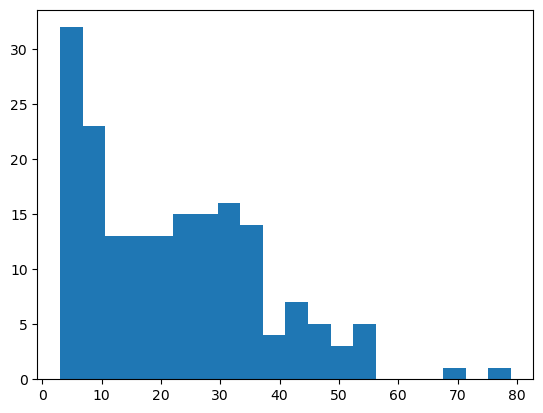

27
79


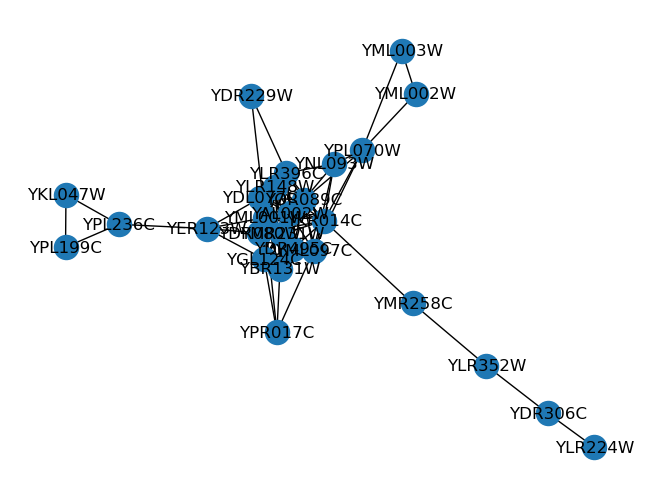

In [2]:
communities = eliminate_small_communities(G, threshold=3, seed=83406, resolution=20)
sizes = np.array(size_distribution_of_communities(communities))

print(f"Average size of communitites: {np.mean(sizes)}")
print(f"Meduan size of communitites: {np.median(sizes)}")

plt.hist(sizes, bins=20)
plt.show()

target, adjacent = get_adjacent_communities(G, communities)
subG = G.subgraph(target)
nx.draw(subG, with_labels=True)
print(len(target))
print(max(sizes))

In [3]:
for com in communities:
    if 'YMR231W' in com:
        print(len(com), com)

27 {'YDR080W', 'YML097C', 'YBR131W', 'YDL077C', 'YGL124C', 'YPL236C', 'YLR148W', 'YNL093W', 'YLR224W', 'YKR014C', 'YER123W', 'YML001W', 'YMR231W', 'YLR352W', 'YPR017C', 'YOR089C', 'YPL070W', 'YDR306C', 'YML003W', 'YML002W', 'YAL002W', 'YMR258C', 'YDR495C', 'YPL199C', 'YKL047W', 'YLR396C', 'YDR229W'}


Average size of communitites: 13.674740484429066
Meduan size of communitites: 12.0


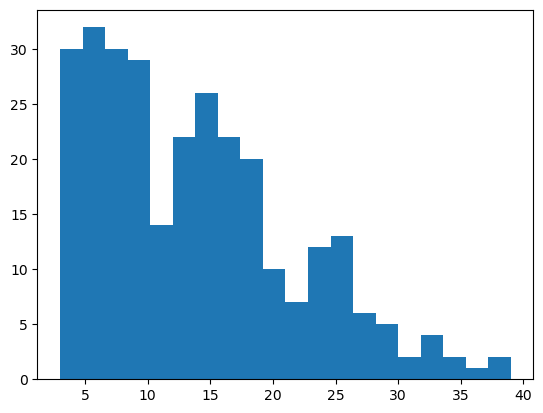

20
39


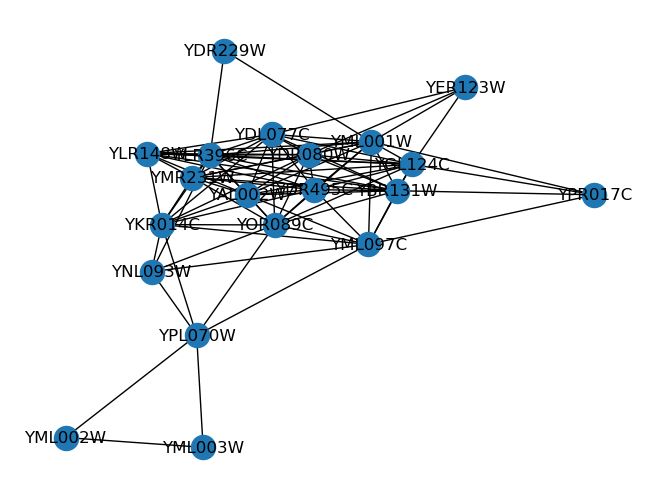

In [4]:
smaller_communities = eliminate_small_communities(G, threshold=3, seed=83406, resolution=50)
sizes = np.array(size_distribution_of_communities(smaller_communities))

print(f"Average size of communitites: {np.mean(sizes)}")
print(f"Meduan size of communitites: {np.median(sizes)}")

plt.hist(sizes, bins=20)
plt.show()

target, adjacent = get_adjacent_communities(G, smaller_communities)
subG = G.subgraph(target)
nx.draw(subG, with_labels=True)
print(len(target))
print(max(sizes))

In [5]:
for com in smaller_communities:
    if 'YMR231W' in com:
        print(len(com), com)

20 {'YDR080W', 'YML097C', 'YBR131W', 'YDL077C', 'YGL124C', 'YLR148W', 'YNL093W', 'YKR014C', 'YER123W', 'YML001W', 'YMR231W', 'YPL070W', 'YPR017C', 'YOR089C', 'YML003W', 'YML002W', 'YAL002W', 'YDR495C', 'YLR396C', 'YDR229W'}


# Stuff with adjacent communities 

In [6]:
communities = eliminate_small_communities(G, threshold=3, seed=83406, resolution=20)
adjacent_communities = get_adjacent_communities(G, communities)


In [14]:
degcent = nx.degree_centrality(G)
eigcent = nx.eigenvector_centrality(G)
ClosenessCent = nx.closeness_centrality(G) # this takes long to calculate; ~40s
Betweencent = nx.betweenness_centrality(G) # this takes long to calculate; ~2m

In [15]:
a = selecting_high_frequency_intermediary_nodes(G, adjacent_communities, degcent)
b = selecting_high_frequency_intermediary_nodes(G, adjacent_communities, eigcent)
c = selecting_high_frequency_intermediary_nodes(G, adjacent_communities, ClosenessCent)
d = selecting_high_frequency_intermediary_nodes(G, adjacent_communities, Betweencent)


In [ ]:
pprint.pprint(compress_important_nodes([a, b, c, d]))


{'YBR028C': {('YBR028C', 8)},
 'YBR118W': {('YBR118W', 4)},
 'YDR494W': {('YDR494W', 6)},
 'YER075C': {('YER075C', 4)},
 'YHL027W': {('YHL027W', 22)},
 'YNL014W': {('YNL014W', 5)},
 'YNL298W': {('YNL298W', 15)},
 'YOR042W': {('YOR042W', 12)},
 'YPL048W': {('YPL048W', 3)}}


### Problem

The above shows a problem with our adjacent communities. This problem can be seen in the following code which prints the path lengths from the community representatives to pep5. As can be seen there, no path has a length greater than 4. This may be a problem with small community partitions? Regardless, the only valuable nodes we would have to offer would be the community representatives themselves.

In [24]:
adjacent_representatives = [
    max(community, key=lambda n: degcent[n])
    for community in adjacent_communities[1]
]
for source in adjacent_representatives:
    print(nx.shortest_path_length(G, source, 'YMR231W'), end=',')

3,3,3,3,3,3,3,4,3,3,2,3,3,3,4,4,3,2,

### Trying with larger community

In [ ]:
large_communities = eliminate_small_communities(G, threshold=3, seed=83406, resolution=1)
adjacent_large_communities = get_adjacent_communities(G, large_communities)

a_L = selecting_high_frequency_intermediary_nodes(G, adjacent_large_communities, degcent, exclude_representatives=True)
b_L = selecting_high_frequency_intermediary_nodes(G, adjacent_large_communities, eigcent, exclude_representatives=True)
c_L = selecting_high_frequency_intermediary_nodes(G, adjacent_large_communities, ClosenessCent, exclude_representatives=True)
d_L = selecting_high_frequency_intermediary_nodes(G, adjacent_large_communities, Betweencent, exclude_representatives=True)


In [ ]:
large_adjacent_representatives = [
    max(community, key=lambda n: degcent[n])
    for community in adjacent_large_communities[1]
]
for source in large_adjacent_representatives:
    print(nx.shortest_path_length(G, source, 'YMR231W'), end=',')
# this one has actual higher degree stuff, more promising

4,3,4,4,4,4,8,4,3,3,3,4,4,6,4,4,

In [54]:
draft_nodes_list = compress_important_nodes([a_L, b_L, c_L, d_L])
pprint.pprint(draft_nodes_list)

{'YAR075W': {('YMR217W', 2), ('YCL068C', 3)},
 'YCL046W': {('YGL115W', 5)},
 'YGL177W': {('YKR092C', 5)},
 'YJR150C': {('YJR047C', 6), ('YDR213W', 3)},
 'YKL224C': {('YJR047C', 6), ('YDR213W', 3)},
 'YLL033W': {('YOR304C-A', 3), ('YFR055W', 3)},
 'YLR369W': {('YNL064C', 11), ('YDR320C', 21), ('YLL041C', 8), ('YMR186W', 9)},
 'YNL050C': {('YLR221C', 3), ('YBL028C', 3), ('YKR092C', 5), ('YBR271W', 3)},
 'YNL140C': {('YBR111W-A', 11),
             ('YDR138W', 7),
             ('YDR159W', 7),
             ('YPL178W', 11)},
 'YNL255C': {('YLR441C', 19), ('YNL254C', 4), ('YHL034C', 2), ('YGR271C-A', 6)},
 'YOR051C': {('YGR118W', 20)}}


In [91]:
pprint.pprint(all_shortest_paths(G, 'YNL140C', 'YMR231W'))

[['YNL140C', 'YHR167W', 'YAL021C', 'YLL013C', 'YML124C', 'YML001W', 'YMR231W'],
 ['YNL140C', 'YHR167W', 'YAL021C', 'YKL025C', 'YML124C', 'YML001W', 'YMR231W'],
 ['YNL140C', 'YHR167W', 'YOR123C', 'YOL012C', 'YML124C', 'YML001W', 'YMR231W'],
 ['YNL140C', 'YNL139C', 'YOR123C', 'YOL012C', 'YML124C', 'YML001W', 'YMR231W'],
 ['YNL140C', 'YHR167W', 'YLR418C', 'YOL012C', 'YML124C', 'YML001W', 'YMR231W'],
 ['YNL140C', 'YNL139C', 'YLR418C', 'YOL012C', 'YML124C', 'YML001W', 'YMR231W'],
 ['YNL140C', 'YHR167W', 'YDR138W', 'YKL003C', 'YOR070C', 'YML001W', 'YMR231W'],
 ['YNL140C', 'YNL139C', 'YDR138W', 'YKL003C', 'YOR070C', 'YML001W', 'YMR231W'],
 ['YNL140C',
  'YNL139C',
  'YBR111W-A',
  'YLL039C',
  'YML097C',
  'YML001W',
  'YMR231W'],
 ['YNL140C', 'YHR167W', 'YAL021C', 'YBL032W', 'YAL029C', 'YNL304W', 'YMR231W'],
 ['YNL140C', 'YHR167W', 'YPL178W', 'YBL032W', 'YAL029C', 'YNL304W', 'YMR231W'],
 ['YNL140C', 'YNL139C', 'YPL178W', 'YBL032W', 'YAL029C', 'YNL304W', 'YMR231W'],
 ['YNL140C', 'YNL139C', 'Y

In [43]:
for y in draft_nodes_list:
    print(y)

YKL224C
YLL033W
YOR051C
YNL255C
YGL177W
YLR369W
YCL046W
YJR150C
YAR075W
YNL140C
YNL050C


# Analysis of Genes

In [42]:
mg = mygene.MyGeneInfo()
mg.getgene('YMR231W')['symbol']

'PEP5'

In [ ]:
mg.getgene('YPL178W')['symbol']

'CBC2'

In [39]:
mg.getgene('YPL178W').values()

dict_values(['SGD:S000006099', 'YPL178W', 'S000006099', 'YPL178W', '855925', 1, {'genomic': ['BK006949.2', 'NC_001148.4'], 'protein': ['DAA11256.1', 'NP_015147.1', 'Q08920.1'], 'rna': 'NM_001183992.1', 'translation': {'protein': 'NP_015147.1', 'rna': 'NM_001183992.1'}}, {'orthologs': [{'algorithmsmatch': '8', 'gene_id': '855925', 'isbestrevscore': True, 'isbestscore': True, 'ortholog_id': '448671', 'outofalgorithms': '9', 'symbol': 'ncbp2', 'taxid': 8364}, {'algorithmsmatch': '7', 'gene_id': '855925', 'isbestrevscore': True, 'isbestscore': True, 'ortholog_id': '192325', 'outofalgorithms': '9', 'symbol': 'ncbp2', 'taxid': 7955}, {'algorithmsmatch': '8', 'gene_id': '855925', 'isbestrevscore': True, 'isbestscore': True, 'ortholog_id': '22916', 'outofalgorithms': '9', 'symbol': 'NCBP2', 'taxid': 9606}, {'algorithmsmatch': '7', 'gene_id': '855925', 'isbestrevscore': True, 'isbestscore': False, 'ortholog_id': '392517', 'outofalgorithms': '9', 'symbol': 'NCBP2L', 'taxid': 9606}, {'algorithmsm

In [ ]:
# Note: It looks like some of last weeks code broke, I presume because of some changes made to get_adjacent_communities when I updated my local repository.
# As such, modified code of last week is this. It essentially just comes down to appending [1] to adjacent communities

# adjacent_representatives_degree = [
#     max(community, key=lambda n: degcent[n])
#     for community in adjacent_communities
# ]

# for source in adjacent_representatives_degree:
#     paths = all_shortest_paths(G, str(source))  # list of paths (each a list of nodes)
#     shortest_path_frequencies = sort_proteins_by_frequency(paths)
#     for i in range(3):
#         if nx.shortest_path_length(G, shortest_path_frequencies[i][0], 'YMR231W') == 4:
#             print(shortest_path_frequencies[i])

In [ ]:
# Also, I wonder about the frequency count being a bit misleading. maybe try to use a density instead of a absolute thing? idk.